<a href="https://colab.research.google.com/github/aaronab810/Dubai-Real-Estate-NLP/blob/main/dfm_transaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
dld_path = '/content/drive/MyDrive/Dubai_Real_Estate_Data/transactions.csv'
dfm_path = '/content/drive/MyDrive/Dubai_Real_Estate_Data/dfm.xlsx'

# 3. Load the raw data into Pandas DataFrames
dld_df = pd.read_csv(dld_path)
dfm_df = pd.read_excel(dfm_path)

# 4. Print the exact column headers so we can plan the merge
print(" DLD Columns ---")
print(dld_df.columns.tolist())
print("\n--- DFM Columns ---")
print(dfm_df.columns.tolist())

 DLD Columns ---
['TRANSACTION_NUMBER', 'INSTANCE_DATE', 'GROUP_EN', 'PROCEDURE_EN', 'IS_OFFPLAN_EN', 'IS_FREE_HOLD_EN', 'USAGE_EN', 'AREA_EN', 'PROP_TYPE_EN', 'PROP_SB_TYPE_EN', 'TRANS_VALUE', 'PROCEDURE_AREA', 'ACTUAL_AREA', 'ROOMS_EN', 'PARKING', 'NEAREST_METRO_EN', 'NEAREST_MALL_EN', 'NEAREST_LANDMARK_EN', 'TOTAL_BUYER', 'TOTAL_SELLER', 'MASTER_PROJECT_EN', 'PROJECT_EN']

--- DFM Columns ---
['Date', 'DFM Index', 'Change', 'Chage %']


In [15]:
import pandas as pd

# 1. Fix the DFM typo
dfm_df.rename(columns={'Chage %': 'Change %'}, inplace=True)

# 2. Convert both date columns to actual Pandas datetime objects
dld_df['INSTANCE_DATE'] = pd.to_datetime(dld_df['INSTANCE_DATE'], errors='coerce')
dfm_df['Date'] = pd.to_datetime(dfm_df['Date'], errors='coerce')

# 3. Filter DLD strictly for NLP correlation (ADDED ACTUAL_AREA!)
dld_features = ['INSTANCE_DATE', 'TRANS_VALUE', 'AREA_EN', 'PROCEDURE_EN', 'ACTUAL_AREA']
dld_clean = dld_df[dld_features].copy()

# 4. Filter for actual Sales using string matching to avoid 0 rows
dld_clean = dld_clean[dld_clean['PROCEDURE_EN'].str.contains('Sale', case=False, na=False)]

print(f"Remaining DLD rows after Sale filter: {len(dld_clean)}")

# 5. Drop the PROCEDURE_EN column now that we're done filtering
dld_clean.drop(columns=['PROCEDURE_EN'], inplace=True)

# 6. Calculate Price per SqFt
# (Adding a small check to drop any rows where area is 0 to avoid math errors)
dld_clean = dld_clean[dld_clean['ACTUAL_AREA'] > 0]
dld_clean['PRICE_SQFT'] = dld_clean['TRANS_VALUE'] / dld_clean['ACTUAL_AREA']

# 7. Group by District and Week
weekly = (dld_clean.groupby([
            'AREA_EN',
            pd.Grouper(key='INSTANCE_DATE', freq='W')
          ])
          .agg(
              transaction_count=('TRANS_VALUE', 'count'),
              median_price_sqft=('PRICE_SQFT', 'median'),
              total_value=('TRANS_VALUE', 'sum')
          )
          .round(2)
          .reset_index()
)

# 8. Sort chronologically per district
weekly = weekly.sort_values(['AREA_EN', 'INSTANCE_DATE'])

print("\nWeekly district aggregation complete.")
print(weekly.head())

Remaining DLD rows after Sale filter: 14140

Weekly district aggregation complete.
     AREA_EN INSTANCE_DATE  transaction_count  median_price_sqft   total_value
0  AL BARARI    2026-01-18                  2           12130.29  5.735223e+06
1  AL BARARI    2026-01-25                  2           58282.26  1.175000e+08
2  AL BARARI    2026-02-01                  2           26582.12  6.450000e+07
3  AL BARARI    2026-02-08                  4           28019.25  1.092500e+08
4  AL BARARI    2026-02-15                 96           18710.20  2.401000e+08


In [16]:
# 1. Calculate the 12-week (3-month) rolling average of the median price per sqft
# We use transform to keep the index aligned, and min_periods=1 so early weeks don't become NaN
weekly['rolling_3m_price_sqft'] = (
    weekly.groupby('AREA_EN')['median_price_sqft']
    .transform(lambda x: x.rolling(window=12, min_periods=1).mean())
    .round(2)
)

# 2. Aggregate DFM data to weekly (taking the last trading day's close for that week)
dfm_weekly = dfm_df.groupby(pd.Grouper(key='Date', freq='W')).agg(
    DFM_Close=('DFM Index', 'last')
).reset_index()

# 3. Rename the DFM date column so it exactly matches the DLD date column
dfm_weekly.rename(columns={'Date': 'INSTANCE_DATE'}, inplace=True)

# 4. Merge the two datasets together using an inner join!
# This ensures we only keep weeks where we have both Real Estate data AND Stock Index data
master_dataset = pd.merge(weekly, dfm_weekly, on='INSTANCE_DATE', how='inner')

print("Target variable calculated and DFM merged successfully.")
print(master_dataset.head())

Target variable calculated and DFM merged successfully.
     AREA_EN INSTANCE_DATE  transaction_count  median_price_sqft  \
0  AL BARARI    2026-01-18                  2           12130.29   
1  AL BARARI    2026-01-25                  2           58282.26   
2  AL BARARI    2026-02-01                  2           26582.12   
3  AL BARARI    2026-02-08                  4           28019.25   
4  AL BARARI    2026-02-15                 96           18710.20   

    total_value  rolling_3m_price_sqft  DFM_Close  
0  5.735223e+06               12130.29    6316.14  
1  1.175000e+08               35206.28    6484.38  
2  6.450000e+07               32331.56    6435.36  
3  1.092500e+08               31253.48    6691.00  
4  2.401000e+08               28744.82    6730.11  


In [17]:
# 1. Define the exact save path in your Google Drive folder
output_path = '/content/drive/MyDrive/Dubai_Real_Estate_Data/dfm_transaction.csv'

# 2. Export the dataframe to a CSV file
# (Setting index=False ensures Pandas doesn't add a weird unnamed number column to the start of your file)
master_dataset.to_csv(output_path, index=False)

print(f"Boom. Baseline locked and loaded.")
print(f"File saved permanently to: {output_path}")

Boom. Baseline locked and loaded.
File saved permanently to: /content/drive/MyDrive/Dubai_Real_Estate_Data/dfm_transaction.csv


In [18]:
print("--- Missing Values Check ---")
print(master_dataset.isnull().sum())

print("\n--- Statistical Sanity Check ---")
# Formatting to avoid scientific notation
pd.set_option('display.float_format', lambda x: '%.2f' % x)
print(master_dataset.describe())

--- Missing Values Check ---
AREA_EN                  0
INSTANCE_DATE            0
transaction_count        0
median_price_sqft        0
total_value              0
rolling_3m_price_sqft    0
DFM_Close                0
dtype: int64

--- Statistical Sanity Check ---
                       INSTANCE_DATE  transaction_count  median_price_sqft  \
count                           1801            1801.00            1801.00   
mean   2026-02-28 02:38:18.722931968               7.85           18964.06   
min              2026-01-04 00:00:00               1.00               3.53   
25%              2026-02-01 00:00:00               1.00           11292.94   
50%              2026-03-01 00:00:00               3.00           15822.95   
75%              2026-03-29 00:00:00               8.00           22982.92   
max              2026-04-26 00:00:00             240.00          344445.28   
std                              NaN              15.09           15786.92   

        total_value  rolling_3m_

In [19]:
# Check the timeline for the district we looked at earlier
al_barari_test = master_dataset[master_dataset['AREA_EN'] == 'AL BARARI'].copy()

print("Checking Al Barari Timeline Sequence...")
print(al_barari_test[['INSTANCE_DATE', 'median_price_sqft', 'rolling_3m_price_sqft', 'DFM_Close']].head(10))

Checking Al Barari Timeline Sequence...
  INSTANCE_DATE  median_price_sqft  rolling_3m_price_sqft  DFM_Close
0    2026-01-18           12130.29               12130.29    6316.14
1    2026-01-25           58282.26               35206.28    6484.38
2    2026-02-01           26582.12               32331.56    6435.36
3    2026-02-08           28019.25               31253.48    6691.00
4    2026-02-15           18710.20               28744.82    6730.11
5    2026-02-22           13001.72               26120.97    6590.53
6    2026-03-01           31620.87               26906.67    6503.50
7    2026-03-08           41900.99               28780.96    5917.22
8    2026-03-15           31432.93               29075.63    5426.28
9    2026-03-22           29718.88               29139.95    5550.24


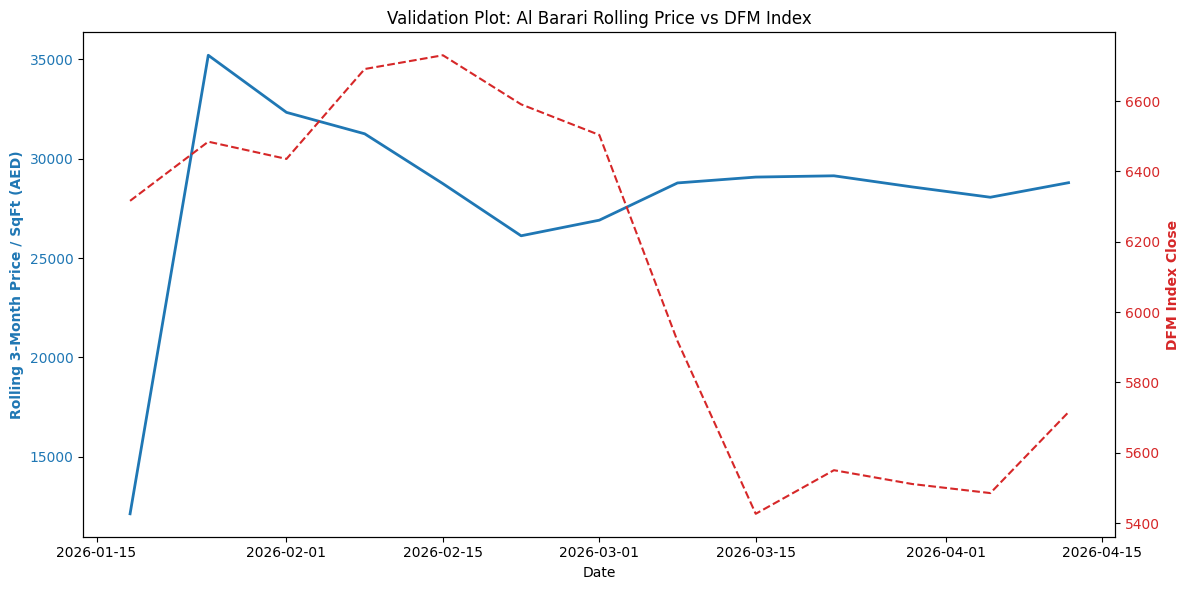

In [20]:
import matplotlib.pyplot as plt

# Plotting the dual-axis chart for Al Barari
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot 1: Your Real Estate Target (Left Axis)
ax1.set_xlabel('Date')
ax1.set_ylabel('Rolling 3-Month Price / SqFt (AED)', color='tab:blue', fontweight='bold')
ax1.plot(al_barari_test['INSTANCE_DATE'], al_barari_test['rolling_3m_price_sqft'], color='tab:blue', label='Smoothed Property Price', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Plot 2: The DFM Index (Right Axis)
ax2 = ax1.twinx()
ax2.set_ylabel('DFM Index Close', color='tab:red', fontweight='bold')
ax2.plot(al_barari_test['INSTANCE_DATE'], al_barari_test['DFM_Close'], color='tab:red', linestyle='--', label='DFM Index')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Validation Plot: Al Barari Rolling Price vs DFM Index')
fig.tight_layout()
plt.show()

In [21]:
# Check which districts have the most 'signal' (transactions)/ see
#which districts actually have enough data to be useful for your FinBERT model

district_stats = (master_dataset.groupby('AREA_EN')
                  .agg(
                      total_weeks=('INSTANCE_DATE', 'count'),
                      avg_weekly_trans=('transaction_count', 'mean'),
                      price_volatility=('median_price_sqft', 'std')
                  )
                  .sort_values('avg_weekly_trans', ascending=False)
)

print("Top 10 Districts by Activity:")
print(district_stats.head(10))

Top 10 Districts by Activity:
                         total_weeks  avg_weekly_trans  price_volatility
AREA_EN                                                                 
Warsan Fourth                      1            142.00               NaN
JUMEIRAH VILLAGE CIRCLE           17             77.41           1159.89
BUSINESS BAY                      17             61.47           1811.44
GARDEN VIEW                        1             40.00               NaN
JUMEIRAH LAKES TOWERS             17             33.88           1533.28
DUBAI MARINA                      17             33.82           2235.92
BURJ KHALIFA                      17             32.59           2685.21
MAJAN                             16             30.81           2307.36
INTERNATIONAL CITY PH 1           17             26.53           1441.11
DISCOVERY GARDENS                 17             24.24            830.06


be 100% sure the rolling average is working correctly for everyone, let’s plot the Top 3 most active districts against the DFM index. If the lines look independent of each other but all follow the DFM timeline, the merge is perfect.

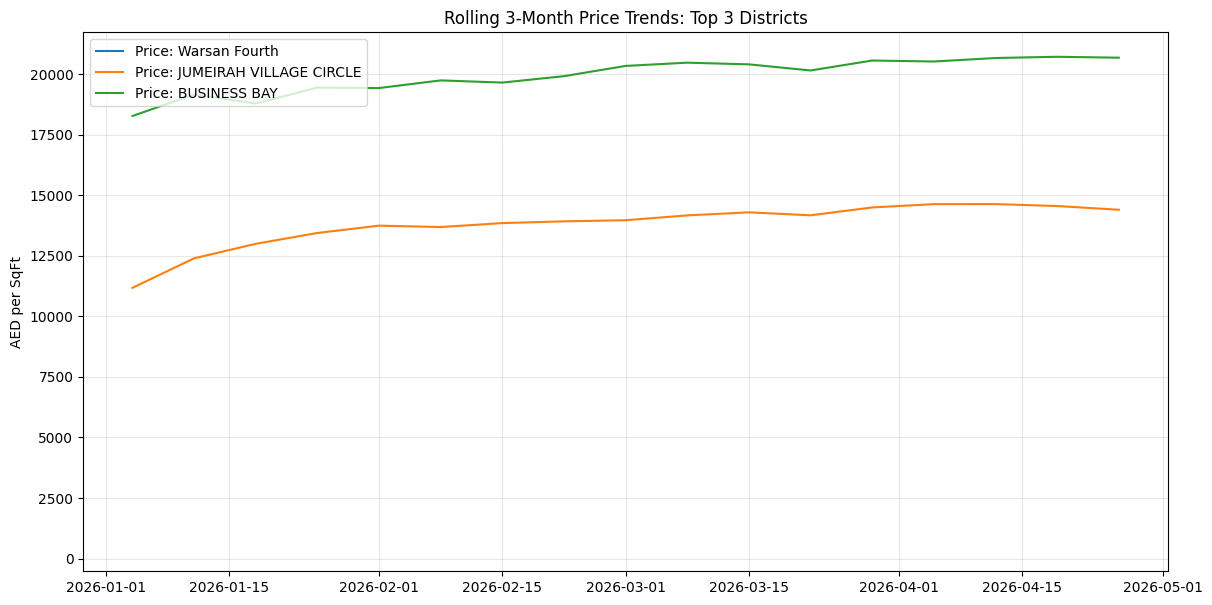

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the names of the top 3 districts
top_districts = district_stats.index[:3].tolist()

plt.figure(figsize=(14, 7))

# Plot the 3-month rolling average for each top district
for district in top_districts:
    subset = master_dataset[master_dataset['AREA_EN'] == district]
    plt.plot(subset['INSTANCE_DATE'], subset['rolling_3m_price_sqft'], label=f'Price: {district}')

plt.title('Rolling 3-Month Price Trends: Top 3 Districts')
plt.ylabel('AED per SqFt')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.show()

need to confirm that your .transform() function stayed within its "lane." If the rolling average for "District A" accidentally included prices from "District B," your AI will learn absolute gibberish.

In [23]:
# Pick two districts with vastly different price points
palm = master_dataset[master_dataset['AREA_EN'].str.contains('PALM', case=False, na=False)]['rolling_3m_price_sqft'].mean()
discovery = master_dataset[master_dataset['AREA_EN'].str.contains('DISCOVERY', case=False, na=False)]['rolling_3m_price_sqft'].mean()

print(f"Average Rolling Price (Palm): {palm:.2f} AED")
print(f"Average Rolling Price (Discovery Gardens): {discovery:.2f} AED")

if abs(palm - discovery) > 500:
    print("\n PASS: Districts are mathematically isolated. No data leakage detected.")
else:
    print("\n WARNING: Prices look suspiciously similar. Double-check the groupby logic.")

Average Rolling Price (Palm): 41616.15 AED
Average Rolling Price (Discovery Gardens): 11196.35 AED

 PASS: Districts are mathematically isolated. No data leakage detected.
